# Evaluation & Analysis
**Task 7 — Dariga Borasheva**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True, parents=True)
PALETTE = {
    'LogisticRegression': '#4C72B0',
    'LinearSVC':          '#DD8452',
    'RoBERTa':            '#55A868',
    'Zero-Shot Baseline': '#4C72B0',
    'Self-Trained Model': '#C44E52',
}
STYLE = dict(dpi=150, bbox_inches='tight')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120


## Results Data


In [2]:
IMDB_RESULTS = {
    'LogisticRegression': {'val':  {'accuracy': 0.8596, 'macro_f1': 0.8596},
                           'test': {'accuracy': 0.8669, 'macro_f1': 0.8669}},
    'LinearSVC':          {'val':  {'accuracy': 0.8613, 'macro_f1': 0.8613},
                           'test': {'accuracy': 0.8671, 'macro_f1': 0.8671}},
    'RoBERTa':            {'val':  {'accuracy': 0.91,   'macro_f1': 0.91},
                           'test': {'accuracy': 0.91,   'macro_f1': 0.9115}},
}
ZEROSHOT_RESULTS = {
    'LogisticRegression': {'accuracy': 0.431,  'macro_f1': 0.4095, 'best_threshold': 0.55},
    'LinearSVC':          {'accuracy': 0.4241, 'macro_f1': 0.4134, 'best_threshold': 0.65},
    'RoBERTa':            {'accuracy': 0.5512, 'macro_f1': 0.5512, 'best_threshold': 0.75},
}
FEW_SHOT_RESULTS = [
    {'k': 0,   'train_size': 0,   'accuracy': 0.5437, 'macro_f1': 0.435},
    {'k': 10,  'train_size': 30,  'accuracy': 0.5515, 'macro_f1': 0.4437},
    {'k': 30,  'train_size': 90,  'accuracy': 0.6921, 'macro_f1': 0.6872},
    {'k': 50,  'train_size': 150, 'accuracy': 0.6969, 'macro_f1': 0.6966},
    {'k': 100, 'train_size': 300, 'accuracy': 0.7139, 'macro_f1': 0.7115},
    {'k': 200, 'train_size': 600, 'accuracy': 0.7202, 'macro_f1': 0.7175},
]
SELF_TRAINING_RESULTS = {
    'accepted_samples': 7199,
    'total_unlabelled': 9283,
    'metrics': [
        {'Model': 'Zero-Shot Baseline', 'Accuracy': 0.5437, 'Macro-F1': 0.435},
        {'Model': 'Self-Trained Model', 'Accuracy': 0.6126, 'Macro-F1': 0.6109},
    ]
}
print('Data ready.')


Data ready.


## 1. IMDb Source Domain Performance


In [3]:
rows = [{'Model': m, 'Accuracy': v['test']['accuracy'], 'Macro-F1': v['test']['macro_f1']}
        for m, v in IMDB_RESULTS.items()]
imdb_df = pd.DataFrame(rows).set_index('Model')
imdb_df


,Accuracy,Macro-F1
Model,,
LogisticRegression,0.8669,0.8669
LinearSVC,0.8671,0.8671
RoBERTa,0.9100,0.9115


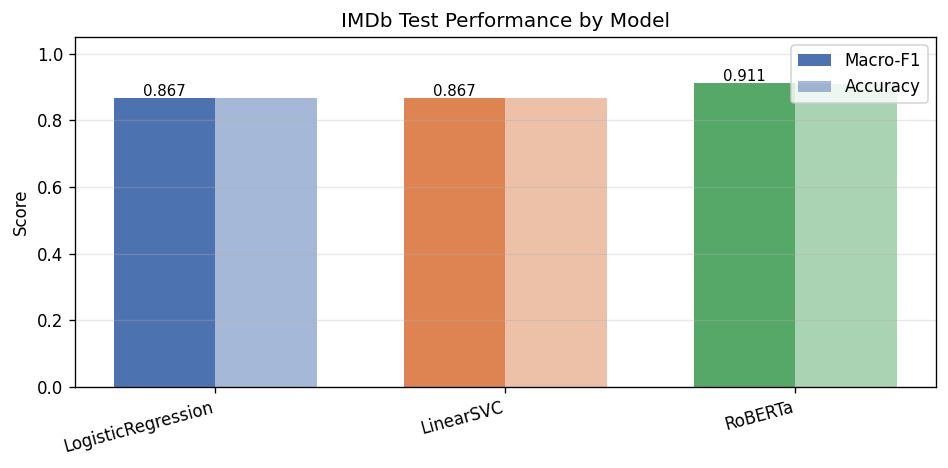

In [4]:
models = list(IMDB_RESULTS.keys())
f1s  = [IMDB_RESULTS[m]['test']['macro_f1'] for m in models]
accs = [IMDB_RESULTS[m]['test']['accuracy']  for m in models]
x, w = np.arange(len(models)), 0.35
fig, ax = plt.subplots(figsize=(8, 4))
colors = [PALETTE.get(m,'#888') for m in models]
ax.bar(x-w/2, f1s,  w, label='Macro-F1', color=colors)
ax.bar(x+w/2, accs, w, label='Accuracy',  color=colors, alpha=0.5)
for i,f in enumerate(f1s): ax.text(i-w/2, f+0.005, f'{f:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_title('IMDb Test Performance by Model')
ax.set_ylabel('Score'); ax.set_ylim(0,1.05); ax.legend(); ax.grid(axis='y',alpha=0.3)
fig.tight_layout(); fig.savefig(FIGURES/'1_imdb_test_performance.png', **STYLE); plt.show()


## 2. Zero-Shot Tweet Performance


In [5]:
rows = [{'Model': m, 'Accuracy': v['accuracy'], 'Macro-F1': v['macro_f1'], 'Best Threshold': v['best_threshold']}
        for m, v in ZEROSHOT_RESULTS.items()]
zs_df = pd.DataFrame(rows).set_index('Model')
zs_df


,Accuracy,Macro-F1,Best Threshold
Model,,,
LogisticRegression,0.4310,0.4095,0.55
LinearSVC,0.4241,0.4134,0.65
RoBERTa,0.5512,0.5512,0.75


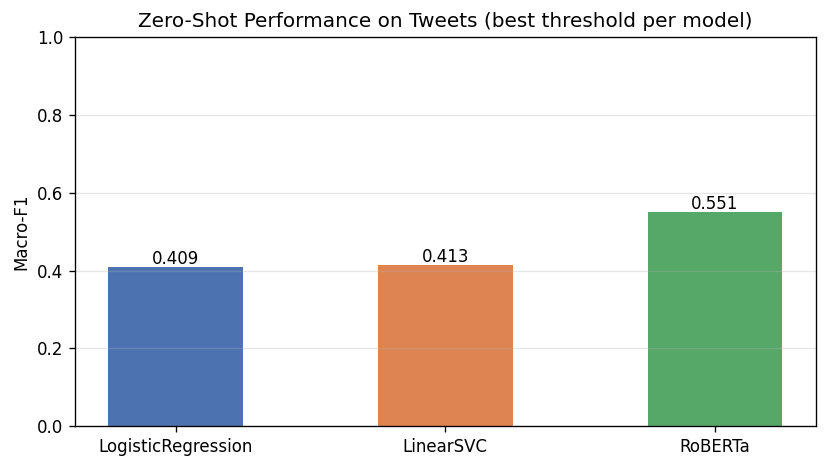

In [6]:
models_zs = list(ZEROSHOT_RESULTS.keys())
f1s_zs = [ZEROSHOT_RESULTS[m]['macro_f1'] for m in models_zs]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models_zs, f1s_zs, color=[PALETTE.get(m,'#888') for m in models_zs], width=0.5)
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.008, f'{b.get_height():.3f}', ha='center', fontsize=10)
ax.set_title('Zero-Shot Performance on Tweets (best threshold per model)')
ax.set_ylabel('Macro-F1'); ax.set_ylim(0,1.0); ax.grid(axis='y',alpha=0.3)
fig.tight_layout(); fig.savefig(FIGURES/'2_zeroshot_tweet_performance.png', **STYLE); plt.show()


## 3. Domain Gap


In [7]:
rows = [{'Model': m,
         'IMDb F1': IMDB_RESULTS[m]['test']['macro_f1'],
         'Tweet F1': ZEROSHOT_RESULTS[m]['macro_f1'],
         'Drop': round(IMDB_RESULTS[m]['test']['macro_f1'] - ZEROSHOT_RESULTS[m]['macro_f1'], 4)}
        for m in IMDB_RESULTS]
gap_df = pd.DataFrame(rows).set_index('Model')
gap_df.style.background_gradient(subset=['Drop'], cmap='RdYlGn_r')


,IMDb F1,Tweet F1,Drop
Model,,,
LogisticRegression,0.866900,0.409500,0.457400
LinearSVC,0.867100,0.413400,0.453700
RoBERTa,0.911500,0.551200,0.360300


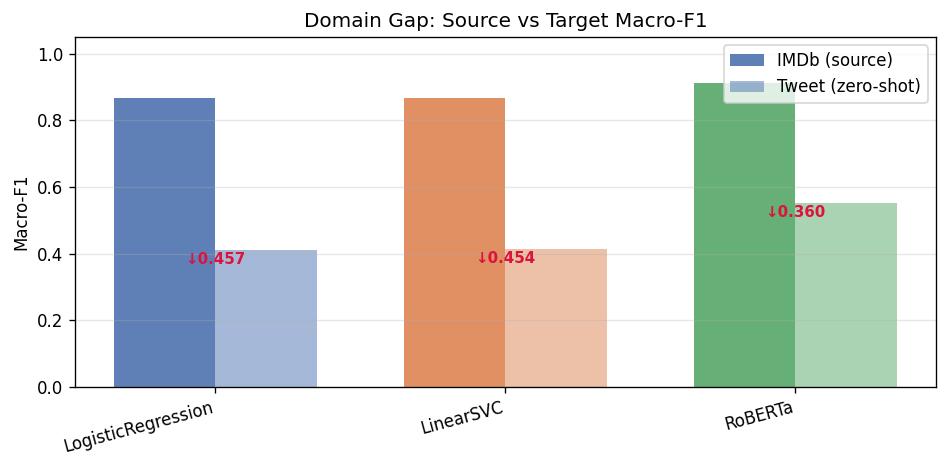

In [8]:
src_f1s = [IMDB_RESULTS[m]['test']['macro_f1'] for m in models]
tgt_f1s = [ZEROSHOT_RESULTS[m]['macro_f1']      for m in models]
x, w = np.arange(len(models)), 0.35
fig, ax = plt.subplots(figsize=(8,4))
colors = [PALETTE.get(m,'#888') for m in models]
ax.bar(x-w/2, src_f1s, w, label='IMDb (source)',     color=colors, alpha=0.9)
ax.bar(x+w/2, tgt_f1s, w, label='Tweet (zero-shot)', color=colors, alpha=0.5)
for i,(s,t) in enumerate(zip(src_f1s,tgt_f1s)):
    ax.annotate(f'↓{s-t:.3f}', xy=(i, min(s,t)-0.04), ha='center', fontsize=9, color='crimson', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_title('Domain Gap: Source vs Target Macro-F1')
ax.set_ylabel('Macro-F1'); ax.set_ylim(0,1.05); ax.legend(); ax.grid(axis='y',alpha=0.3)
fig.tight_layout(); fig.savefig(FIGURES/'3_domain_gap.png', **STYLE); plt.show()


## 4. Few-Shot Learning Curve


In [9]:
fs_df = pd.DataFrame(FEW_SHOT_RESULTS)
fs_df['label'] = fs_df['k'].apply(lambda k: 'Zero-shot' if k==0 else f'K={k}')
fs_df.set_index('label')[['train_size','accuracy','macro_f1']]


,train_size,accuracy,macro_f1
label,,,
Zero-shot,0,0.5437,0.4350
K=10,30,0.5515,0.4437
K=30,90,0.6921,0.6872
K=50,150,0.6969,0.6966
K=100,300,0.7139,0.7115
K=200,600,0.7202,0.7175


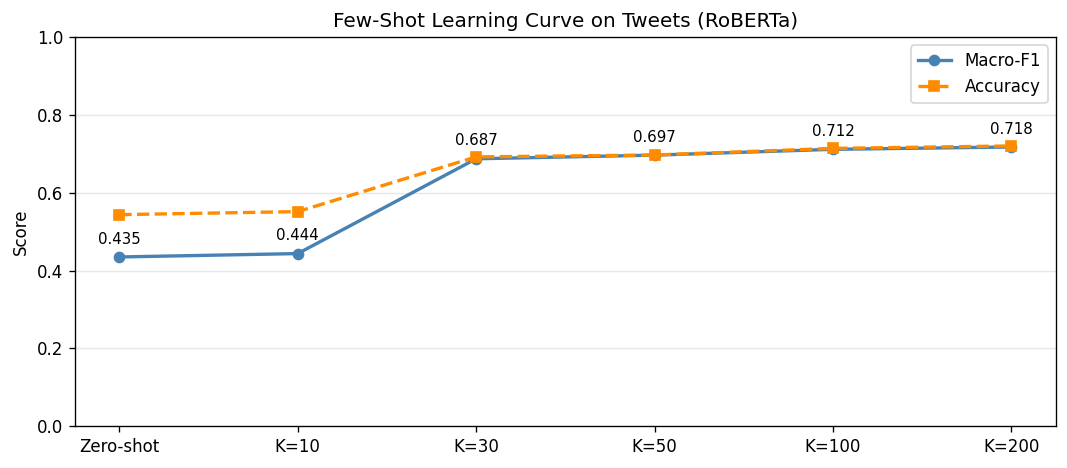

In [10]:
ks      = fs_df['k'].tolist()
f1s_fs  = fs_df['macro_f1'].tolist()
accs_fs = fs_df['accuracy'].tolist()
xlabels = ['Zero-shot' if k==0 else f'K={k}' for k in ks]
x_fs    = np.arange(len(ks))
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(x_fs, f1s_fs,  marker='o', label='Macro-F1', color='steelblue',  linewidth=2)
ax.plot(x_fs, accs_fs, marker='s', label='Accuracy',  color='darkorange', linewidth=2, linestyle='--')
for i,f in enumerate(f1s_fs):
    ax.annotate(f'{f:.3f}',(i,f),textcoords='offset points',xytext=(0,8),ha='center',fontsize=9)
ax.set_xticks(x_fs); ax.set_xticklabels(xlabels)
ax.set_title('Few-Shot Learning Curve on Tweets (RoBERTa)')
ax.set_ylabel('Score'); ax.set_ylim(0,1.0); ax.legend(); ax.grid(axis='y',alpha=0.3)
fig.tight_layout(); fig.savefig(FIGURES/'4_few_shot_learning_curve.png', **STYLE); plt.show()


## 5. Self-Training Adaptation


In [11]:
st_metrics = SELF_TRAINING_RESULTS['metrics']
print(f"Accepted pseudo-labels: {SELF_TRAINING_RESULTS['accepted_samples']:,} / {SELF_TRAINING_RESULTS['total_unlabelled']:,}")
pd.DataFrame(st_metrics).set_index('Model')


Accepted pseudo-labels: 7,199 / 9,283


,Accuracy,Macro-F1
Model,,
Zero-Shot Baseline,0.5437,0.4350
Self-Trained Model,0.6126,0.6109


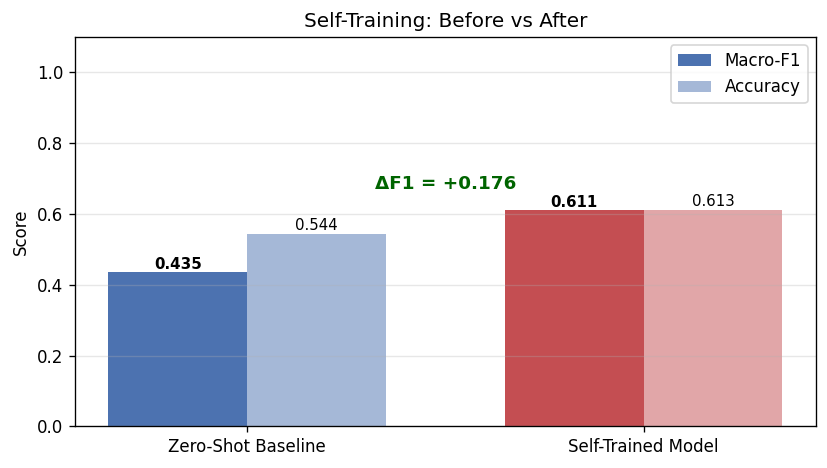

In [12]:
st_models = [m['Model']    for m in st_metrics]
st_f1s    = [m['Macro-F1'] for m in st_metrics]
st_accs   = [m['Accuracy'] for m in st_metrics]
x, w = np.arange(len(st_models)), 0.35
colors_st = [PALETTE.get(m,'#888') for m in st_models]
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x-w/2, st_f1s, w, label='Macro-F1', color=colors_st)
ax.bar(x+w/2, st_accs,w, label='Accuracy',  color=colors_st, alpha=0.5)
for i,(f,a) in enumerate(zip(st_f1s,st_accs)):
    ax.text(i-w/2, f+0.01, f'{f:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i+w/2, a+0.01, f'{a:.3f}', ha='center', fontsize=9)
if len(st_f1s)==2:
    delta=st_f1s[1]-st_f1s[0]; sign='+' if delta>=0 else ''
    ax.annotate(f'ΔF1 = {sign}{delta:.3f}', xy=(0.5, max(st_f1s)+0.06),
                xycoords=('data','data'), ha='center', fontsize=11,
                color='darkgreen' if delta>0 else 'crimson', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(st_models)
ax.set_title('Self-Training: Before vs After')
ax.set_ylabel('Score'); ax.set_ylim(0,1.1); ax.legend(); ax.grid(axis='y',alpha=0.3)
fig.tight_layout(); fig.savefig(FIGURES/'5_self_training_comparison.png', **STYLE); plt.show()


## 6. Full Summary (4-panel)


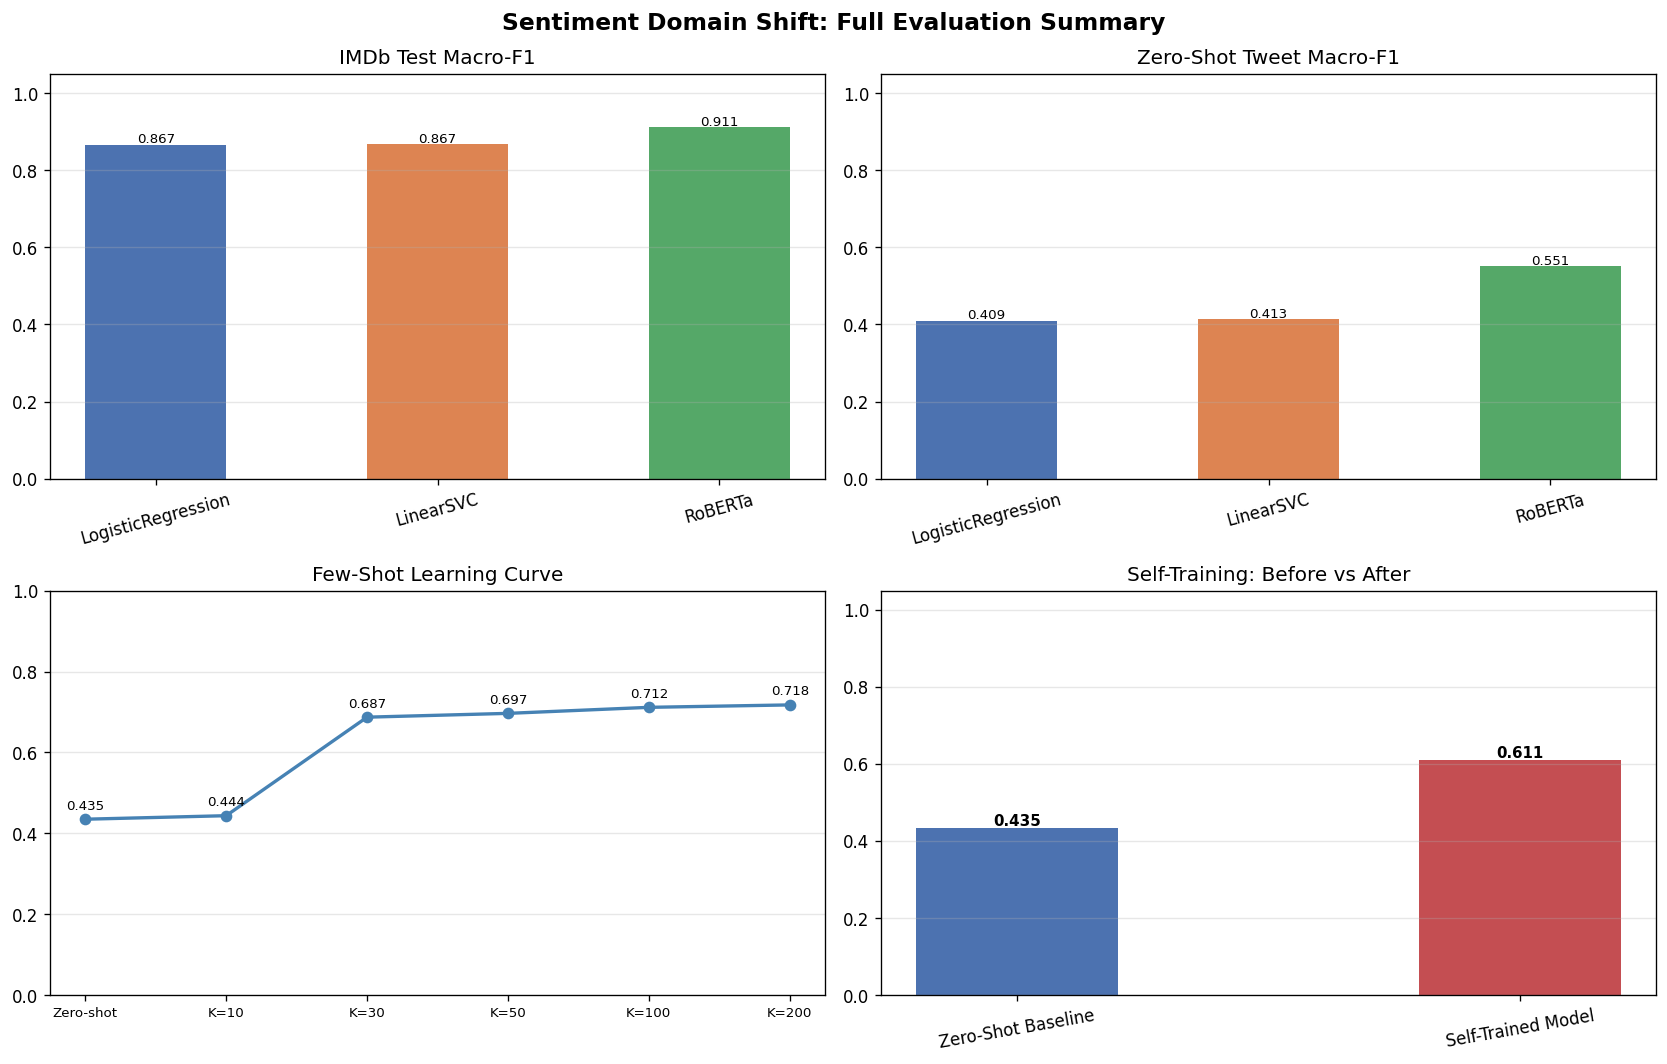

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Sentiment Domain Shift: Full Evaluation Summary', fontsize=14, fontweight='bold')
ax = axes[0,0]
bars = ax.bar(models, f1s, color=[PALETTE.get(m,'#888') for m in models], width=0.5)
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}', ha='center', fontsize=8)
ax.set_title('IMDb Test Macro-F1'); ax.set_ylim(0,1.05); ax.tick_params(axis='x',rotation=15); ax.grid(axis='y',alpha=0.3)
ax = axes[0,1]
bars = ax.bar(models_zs, f1s_zs, color=[PALETTE.get(m,'#888') for m in models_zs], width=0.5)
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}', ha='center', fontsize=8)
ax.set_title('Zero-Shot Tweet Macro-F1'); ax.set_ylim(0,1.05); ax.tick_params(axis='x',rotation=15); ax.grid(axis='y',alpha=0.3)
ax = axes[1,0]
ax.plot(x_fs, f1s_fs, marker='o', color='steelblue', linewidth=2)
for i,f in enumerate(f1s_fs): ax.annotate(f'{f:.3f}',(i,f),textcoords='offset points',xytext=(0,6),ha='center',fontsize=8)
ax.set_xticks(x_fs); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_title('Few-Shot Learning Curve'); ax.set_ylim(0,1.0); ax.grid(axis='y',alpha=0.3)
ax = axes[1,1]
bars = ax.bar(st_models, st_f1s, color=[PALETTE.get(m,'#888') for m in st_models], width=0.4)
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Self-Training: Before vs After'); ax.set_ylim(0,1.05); ax.tick_params(axis='x',rotation=10); ax.grid(axis='y',alpha=0.3)
fig.tight_layout(); fig.savefig(FIGURES/'6_full_summary.png', **STYLE); plt.show()
